# 05: Gradient Boosting (2025 SHED)

Predict `financially_fragile`: whether a respondent could not cover a $400 emergency expense with cash or its equivalent.

In [2]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.metrics import (
    accuracy_score, average_precision_score, brier_score_loss,
    confusion_matrix, f1_score, log_loss, precision_score,
    recall_score, roc_auc_score,
)

RANDOM_STATE = 46796
THRESHOLD = 0.5

## Load the modeling data

In [3]:
DATA_DIR = Path(".")
if not (DATA_DIR / "model_dataset_2025.csv").exists():
    DATA_DIR = Path("../data/processed")

data = pd.read_csv(DATA_DIR / "model_dataset_2025.csv", low_memory=False)
with open(DATA_DIR / "model_dataset_2025_spec.json", encoding="utf-8") as f:
    spec = json.load(f)

TARGET = spec["target"]["column"]
WEIGHT = spec["weight"]
NUMERIC = spec["features"]["numeric"]
CATEGORICAL = spec["features"]["categorical"]
ORDINAL = spec["features"]["ordinal"]
FEATURES = NUMERIC + CATEGORICAL + ORDINAL
FEATURES_NO_EF = [col for col in FEATURES if col not in spec["ef_module"]]

# Using only approved features
required = FEATURES + [TARGET, WEIGHT, spec["id"], "split", "cv_fold"]
assert set(required).issubset(data.columns), "The modeling dataset is missing columns."
assert len(FEATURES) == len(set(FEATURES)), "The feature list contains duplicates."
excluded = {col for columns in spec["excluded"].values() for col in columns}
assert not set(FEATURES) & (excluded | {TARGET, "split", "cv_fold"})
assert data[spec["id"]].notna().all() and data[spec["id"]].is_unique
assert data[TARGET].notna().all() and set(data[TARGET].unique()) == {0, 1}
assert np.isfinite(data[WEIGHT]).all() and (data[WEIGHT] > 0).all()
assert set(data["split"].unique()) == {"train", "test"}

train = data.loc[data["split"] == "train"].copy()
test = data.loc[data["split"] == "test"].copy()
folds = sorted(train["cv_fold"].unique())
assert folds == list(range(spec["cv"]["n_folds"]))
assert (test["cv_fold"] == spec["cv"]["test_fold"]).all()
for fold in folds:
    assert train.loc[train["cv_fold"] == fold, TARGET].nunique() == 2
assert test[TARGET].nunique() == 2

X_train, y_train, w_train = train[FEATURES], train[TARGET], train[WEIGHT]
X_test, y_test, w_test = test[FEATURES], test[TARGET], test[WEIGHT]
print(f"Train: {len(train):,} rows; test: {len(test):,} rows")
print(f"Features: {len(FEATURES)} with EF; {len(FEATURES_NO_EF)} without EF")
print(f"Weighted training fragility rate: {np.average(y_train, weights=w_train):.1%}")

Train: 10,347 rows; test: 2,587 rows
Features: 425 with EF; 409 without EF
Weighted training fragility rate: 36.8%


## Preprocessing

Trees do not need scaling. Keep the same feature types and ordinal orders as the baseline. Existing `__NOT_ASKED__` responses remain separate categories. Imputation and encoding are fitted on training rows only.

In [4]:
def build_preprocessor(features):
    numeric = [col for col in NUMERIC if col in features]
    categorical = [col for col in CATEGORICAL if col in features]
    ordinal = [col for col in ORDINAL if col in features]

    numeric_pipeline = Pipeline([
        ("impute", SimpleImputer(strategy="median", add_indicator=True,
                                keep_empty_features=True)),
    ])
    categorical_pipeline = Pipeline([
        ("impute", SimpleImputer(strategy="constant", fill_value="__MISSING__")),
        ("encode", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
    ])
    ordinal_pipeline = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("encode", OrdinalEncoder(
            categories=[spec["features"]["ordinal_order"][col] for col in ordinal],
            handle_unknown="use_encoded_value", unknown_value=-1,
        )),
    ])
    return ColumnTransformer([
        ("numeric", numeric_pipeline, numeric),
        ("categorical", categorical_pipeline, categorical),
        ("ordinal", ordinal_pipeline, ordinal),
    ], sparse_threshold=1.0)


def build_classifier(params):
    # Shallow trees keep our first model reasonably conservative.
    return GradientBoostingClassifier(
        loss="log_loss", min_samples_leaf=20,
        random_state=RANDOM_STATE, **params,
    )


def build_model(params, features):
    return Pipeline([
        ("preprocess", build_preprocessor(features)),
        ("model", build_classifier(params)),
    ])

## Choose settings on the shared CV folds

Try a small set of tree counts, learning rates, and depths. Select the lowest mean population-weighted validation log loss, as in the logistic regression notebook. The test set is not used to choose settings or the classification threshold.

In [ ]:
PARAMETERS = [
    {"n_estimators": 100, "learning_rate": 0.05, "max_depth": 2},
    {"n_estimators": 200, "learning_rate": 0.05, "max_depth": 2},
    {"n_estimators": 100, "learning_rate": 0.1, "max_depth": 2},
    {"n_estimators": 100, "learning_rate": 0.05, "max_depth": 3},
]


def tune_boosting(features):
    scores = []
    for fold in folds:
        fit_rows = train["cv_fold"] != fold
        valid_rows = train["cv_fold"] == fold
        prep = build_preprocessor(features)

        # Reuse this fold's encoding across settings, but never across folds.
        X_fit = prep.fit_transform(X_train.loc[fit_rows, features])
        X_valid = prep.transform(X_train.loc[valid_rows, features])
        fit_weights = w_train.loc[fit_rows]
        fit_weights = fit_weights / fit_weights.mean()

        for setting, params in enumerate(PARAMETERS):
            model = build_classifier(params)
            model.fit(X_fit, y_train.loc[fit_rows], sample_weight=fit_weights)
            p_valid = model.predict_proba(X_valid)[:, 1]
            scores.append({
                "setting": setting, "fold": fold,
                "log_loss": log_loss(y_train.loc[valid_rows], p_valid,
                                     sample_weight=w_train.loc[valid_rows]),
                "roc_auc": roc_auc_score(y_train.loc[valid_rows], p_valid,
                                         sample_weight=w_train.loc[valid_rows]),
            })
        print(f"Finished fold {int(fold) + 1} of {len(folds)}")

    summary = pd.DataFrame(scores).groupby("setting").agg(
        mean_log_loss=("log_loss", "mean"),
        log_loss_sd=("log_loss", "std"),
        mean_roc_auc=("roc_auc", "mean"),
    )
    summary = pd.DataFrame(PARAMETERS).join(summary)
    best_setting = summary["mean_log_loss"].idxmin()
    return summary, PARAMETERS[int(best_setting)].copy()


cv_results, best_params = tune_boosting(FEATURES)
display(cv_results.round(4))
print("Selected settings:", best_params)

Finished fold 1 of 5
Finished fold 2 of 5
Finished fold 3 of 5
Finished fold 4 of 5


## Fit final model

In [ ]:
final_model = build_model(best_params, FEATURES)
final_model.fit(
    X_train, y_train,
    model__sample_weight=w_train / w_train.mean(),
)
p_test = pd.Series(final_model.predict_proba(X_test)[:, 1], index=test.index)
assert np.isfinite(p_test).all() and p_test.between(0, 1).all()

## Test performance

In [ ]:
#tons of prelim eval work here
def evaluate(y_true, probabilities, weights):
    predicted = np.asarray(probabilities) >= THRESHOLD
    return {
        "ROC AUC": roc_auc_score(y_true, probabilities, sample_weight=weights),
        "PR AUC": average_precision_score(y_true, probabilities, sample_weight=weights),
        "Brier": brier_score_loss(y_true, probabilities, sample_weight=weights),
        "Log loss": log_loss(y_true, probabilities, sample_weight=weights),
        "Accuracy": accuracy_score(y_true, predicted, sample_weight=weights),
        "Recall": recall_score(y_true, predicted, sample_weight=weights, zero_division=0),
        "Precision": precision_score(y_true, predicted, sample_weight=weights, zero_division=0),
        "F1": f1_score(y_true, predicted, sample_weight=weights, zero_division=0),
    }


train_rate = np.average(y_train, weights=w_train)
rng = np.random.default_rng(RANDOM_STATE)
references = {
    "Majority class": np.full(len(test), float(train_rate >= 0.5)),
    "Weighted random": (rng.random(len(test)) < train_rate).astype(float),
    "Training prevalence": np.full(len(test), train_rate),
    "Gradient boosting (with EF)": p_test,
}
results = pd.DataFrame({
    name: evaluate(y_test, p, w_test) for name, p in references.items()
}).T
display(results.round(3))

# Rows = actual classes & columns = predicted classes
labels = ["Not fragile", "Fragile"]
counts = confusion_matrix(y_test, p_test >= THRESHOLD, labels=[0, 1])
weighted = confusion_matrix(y_test, p_test >= THRESHOLD, labels=[0, 1],
                            sample_weight=w_test)
display(pd.DataFrame(counts, index=labels, columns=labels)
        .rename_axis(index="Actual", columns="Predicted"))
display(pd.DataFrame(100 * weighted / weighted.sum(), index=labels, columns=labels)
        .rename_axis(index="Actual (% of weighted test sample)", columns="Predicted").round(1))

                             ROC AUC  PR AUC  Brier  ...  Recall  Precision     F1
Majority class                 0.500   0.370  0.370  ...   0.000      0.000  0.000
Weighted random                0.492   0.367  0.473  ...   0.358      0.361  0.360
Training prevalence            0.500   0.370  0.233  ...   0.000      0.000  0.000
Gradient boosting (with EF)    0.929   0.881  0.101  ...   0.782      0.825  0.803

[4 rows x 8 columns]

Predicted    Not fragile  Fragile
Actual                           
Not fragile         1536      144
Fragile              209      698

Predicted                           Not fragile  Fragile
Actual (% of weighted test sample)                      
Not fragile                                56.8      6.1
Fragile                                     8.1     29.0

## Calibration

Expected calibration error: 0.020


                  rows  mean_predicted  observed_rate
bin                                                  
(0.0191, 0.0285]   259           0.025          0.013
(0.0285, 0.0367]   259           0.032          0.007
(0.0367, 0.0526]   258           0.043          0.022
(0.0526, 0.0839]   259           0.066          0.084
(0.0839, 0.154]    259           0.114          0.101
(0.154, 0.31]      258           0.224          0.273
(0.31, 0.567]      259           0.442          0.429
(0.567, 0.825]     258           0.703          0.728
(0.825, 0.93]      259           0.886          0.900
(0.93, 0.978]      259           0.953          0.944

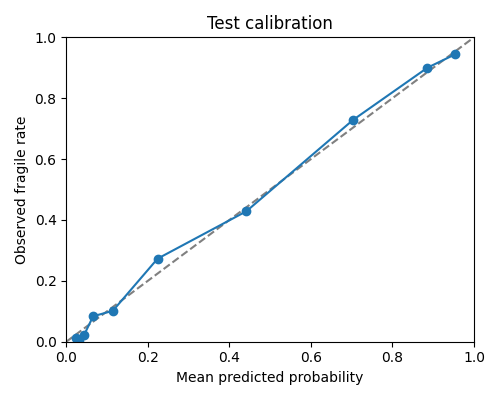

In [ ]:
def weighted_calibration(y_true, probabilities, weights):
    frame = pd.DataFrame({"actual": np.asarray(y_true),
                          "predicted": np.asarray(probabilities),
                          "weight": np.asarray(weights)})
    frame["bin"] = pd.qcut(frame["predicted"], q=10, duplicates="drop")
    frame["weighted_actual"] = frame["actual"] * frame["weight"]
    frame["weighted_predicted"] = frame["predicted"] * frame["weight"]
    table = frame.groupby("bin", observed=True).agg(
        rows=("actual", "size"), weight=("weight", "sum"),
        weighted_actual=("weighted_actual", "sum"),
        weighted_predicted=("weighted_predicted", "sum"),
    )
    table["mean_predicted"] = table["weighted_predicted"] / table["weight"]
    table["observed_rate"] = table["weighted_actual"] / table["weight"]
    ece = np.average(abs(table["mean_predicted"] - table["observed_rate"]),
                     weights=table["weight"])
    return table[["rows", "mean_predicted", "observed_rate"]], ece


calibration, ece = weighted_calibration(y_test, p_test, w_test)
display(calibration.round(3))
print(f"Expected calibration error: {ece:.3f}")
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot([0, 1], [0, 1], "--", color="gray")
ax.plot(calibration["mean_predicted"], calibration["observed_rate"], "o-")
ax.set(xlabel="Mean predicted probability", ylabel="Observed fragile rate",
       title="Test calibration", xlim=(0, 1), ylim=(0, 1))
fig.tight_layout()
plt.show()

In [ ]:
audit_rows = []
for column in ["race_5cat", "ppgender", "ppagecat", "pppa_lgb"]:
    for group, index in test.groupby(column, dropna=False).groups.items():
        yt, pt, wt = y_test.loc[index], p_test.loc[index], w_test.loc[index]
        actual_rate = np.average(yt, weights=wt)
        predicted_rate = np.average(pt, weights=wt)
        audit_rows.append({
            "attribute": column, "group": group, "rows": len(index),
            "actual rate": actual_rate, "mean predicted": predicted_rate,
            "gap (pred - actual)": predicted_rate - actual_rate,
            "recall": recall_score(yt, pt >= THRESHOLD, sample_weight=wt,
                                   zero_division=0) if yt.sum() else np.nan,
            "ROC AUC": roc_auc_score(yt, pt, sample_weight=wt)
                       if yt.nunique() == 2 else np.nan,
            "Brier": brier_score_loss(yt, pt, sample_weight=wt),
            "note": "small group" if len(index) < 100 else "",
        })
audit = pd.DataFrame(audit_rows)
display(audit.set_index(["attribute", "group"]).round(3))

                                      rows  actual rate  ...  Brier         note
attribute group                                          ...                    
race_5cat Asian                        142        0.236  ...  0.093             
          Black                        319        0.633  ...  0.146             
          Hispanic                     339        0.505  ...  0.104             
          Other                         64        0.686  ...  0.124  small group
          White                       1723        0.277  ...  0.090             
ppgender  Female                      1272        0.391  ...  0.100             
          Male                        1315        0.350  ...  0.101             
ppagecat  18-24                        208        0.566  ...  0.137             
          25-34                        355        0.480  ...  0.103             
          35-44                        435        0.474  ...  0.119             
          45-54             

## Features used most by the trees

Trying to describe how the trees reduce loss, not whether a feature increases risk or causes financial fragility! 

In [ ]:
prep = final_model.named_steps["preprocess"]
encoded_names = prep.get_feature_names_out()
encoded_importance = final_model.named_steps["model"].feature_importances_
importance_rows = []
for name, value in zip(encoded_names, encoded_importance):
    transformer, detail = name.split("__", 1)
    if transformer == "categorical":
        original = next(col for col in sorted(CATEGORICAL, key=len, reverse=True)
                        if detail.startswith(col + "_"))
    elif detail.startswith("missingindicator_"):
        original = detail.removeprefix("missingindicator_")
    else:
        original = detail
    importance_rows.append({"feature": original, "importance": value})
importance = (pd.DataFrame(importance_rows).groupby("feature")["importance"]
              .sum().sort_values(ascending=False))
display(importance.head(20).to_frame().round(4))

              importance
feature                 
EF2               0.3721
EF1               0.1508
C4A               0.0889
B2                0.0461
A6                0.0409
FD3               0.0361
atleast_okay      0.0340
EF7               0.0302
EF7A              0.0223
inc_4cat_50k      0.0188
EF8_b             0.0187
K21_d             0.0186
EF8_h             0.0095
I20               0.0089
EF8_d             0.0073
B1_a              0.0070
INF3_d            0.0063
EF8_e             0.0053
EF8_f             0.0052
EF8_a             0.0051

## Sensitivity check without EF questions

Attempting to retune and refit without the EF module to see how much performance changes.

In [ ]:
cv_results_no_ef, best_params_no_ef = tune_boosting(FEATURES_NO_EF)
display(cv_results_no_ef.round(4))
print("Selected settings without EF:", best_params_no_ef)

model_no_ef = build_model(best_params_no_ef, FEATURES_NO_EF)
model_no_ef.fit(
    X_train[FEATURES_NO_EF], y_train,
    model__sample_weight=w_train / w_train.mean(),
)
p_test_no_ef = model_no_ef.predict_proba(X_test[FEATURES_NO_EF])[:, 1]
results.loc["Gradient boosting (without EF)"] = evaluate(y_test, p_test_no_ef, w_test)
display(results.round(3))
display(results.loc[["Gradient boosting (with EF)",
                     "Gradient boosting (without EF)"]].round(3))